## Python para Análisis de Datos: Guía de Inicio Rápido

### Librerías Esenciales para el Análisis de Datos en Python

Para el análisis de datos en Python, `pandas` y `seaborn` son dos librerías fundamentales.

*   **`pandas`**: Proporciona estructuras de datos de alto rendimiento y fáciles de usar, así como herramientas de análisis de datos, destacando el DataFrame.
*   **`seaborn`**: Una librería de visualización de datos estadísticos basada en `matplotlib`, que ofrece una interfaz de alto nivel para dibujar gráficos estadísticos atractivos e informativos.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")

Libraries loaded successfully!


### El DataFrame de `pandas`: Estructura Básica y Objetos

Un `DataFrame` es una estructura de datos tabular bidimensional, de tamaño mutable y potencialmente heterogénea, con ejes etiquetados (filas y columnas). Es similar a una hoja de cálculo o una tabla SQL, o un diccionario de objetos Series.

Cada columna en un DataFrame es esencialmente un objeto `Series`, que es una matriz unidimensional etiquetada capaz de contener cualquier tipo de dato.

In [ ]:
# Create a sample DataFrame
data = {
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve'],
    'Age': [24, 27, 22, 32, 29],
    'City': ['New York', 'Los Angeles', 'Chicago', 'Houston', 'Phoenix'],
    'Score': [85.5, 90.1, 78.9, 92.3, 88.0],
    'Is_Student': [True, False, True, False, True]
}
df = pd.DataFrame(data)

print("Sample DataFrame:")
display(df)

print("\nType of df:", type(df))
print("Type of a column (e.g., 'Name'):", type(df['Name']))

Sample DataFrame:


,Name,Age,City,Score,Is_Student
0,Alice,24,New York,85.5,True
1,Bob,27,Los Angeles,90.1,False
2,Charlie,22,Chicago,78.9,True
3,David,32,Houston,92.3,False
4,Eve,29,Phoenix,88.0,True



Type of df: <class 'pandas.core.frame.DataFrame'>
Type of a column (e.g., 'Name'): <class 'pandas.core.series.Series'>


### Tipos de Datos y Clasificación de Variables

Comprender los tipos de datos es crucial para un análisis efectivo. `pandas` infiere automáticamente los tipos de datos al cargar la información, pero también se pueden convertir explícitamente.

Tipos de datos comunes de `pandas` (`dtype`):
*   **`int64`**: Números enteros.
*   **`float64`**: Números de punto flotante (decimales).
*   **`object`**: Típicamente cadenas de texto o tipos mixtos.
*   **`bool`**: Valores booleanos (Verdadero/Falso).
*   **`datetime64`**: Valores de fecha y hora.

Desde una perspectiva estadística, las variables se pueden clasificar como:
*   **Numéricas**: `Age`, `Score` (pueden ser `int64` o `float64`).
*   **Categóricas**: `City`, `Name` (a menudo `object`, se pueden convertir al tipo `category` para mayor eficiencia).
*   **Booleanas**: `Is_Student` (`bool`).

In [ ]:
print("DataFrame Information and Data Types:")
df.info()

print("\nSummary of numerical columns:")
display(df.describe())

DataFrame Information and Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Name        5 non-null      object 
 1   Age         5 non-null      int64  
 2   City        5 non-null      object 
 3   Score       5 non-null      float64
 4   Is_Student  5 non-null      bool   
dtypes: bool(1), float64(1), int64(1), object(2)
memory usage: 297.0+ bytes

Summary of numerical columns:


,Age,Score
count,5.000000,5.000000
mean,26.800000,86.960000
std,3.962323,5.161201
min,22.000000,78.900000
25%,24.000000,85.500000
50%,27.000000,88.000000
75%,29.000000,90.100000
max,32.000000,92.300000


### Funciones Principales para la Manipulación de Datos

Los equivalentes de `pandas` para funciones comunes de `dplyr` (R):

*   **`mutate` (crear/transformar columnas)**: En `pandas`, puedes asignar nuevas columnas directamente o usar el método `.assign()`.
*   **`inner_join` (combinar dataframes)**: Usa `pd.merge()`.
*   **`filter` (subconjunto de filas)**: Usa indexación booleana (`df[condicion]`), `.loc[]`, o `.query()`.
*   **`select` (subconjunto de columnas)**: Selecciona columnas por nombre `df[['col1', 'col2']]` o usa `.loc[]`.

In [ ]:
# Equivalent of `mutate`: Creating a new column 'Score_Category'
df['Score_Category'] = pd.cut(df['Score'], bins=[0, 80, 90, 100], labels=['Low', 'Medium', 'High'])
display(df)

,Name,Age,City,Score,Is_Student,Score_Category
0,Alice,24,New York,85.5,True,Medium
1,Bob,27,Los Angeles,90.1,False,High
2,Charlie,22,Chicago,78.9,True,Low
3,David,32,Houston,92.3,False,High
4,Eve,29,Phoenix,88.0,True,Medium


In [ ]:
# Equivalent of `inner_join`: Merging DataFrames
other_data = {
    'Name': ['Alice', 'Bob', 'Eve'],
    'Department': ['HR', 'Finance', 'Marketing']
}
df_dept = pd.DataFrame(other_data)

df_merged = pd.merge(df, df_dept, on='Name', how='inner')
print("DataFrame after inner join:")
display(df_merged)

DataFrame after inner join:


,Name,Age,City,Score,Is_Student,Score_Category,Department
0,Alice,24,New York,85.5,True,Medium,HR
1,Bob,27,Los Angeles,90.1,False,High,Finance
2,Eve,29,Phoenix,88.0,True,Medium,Marketing


In [ ]:
# Equivalent of `filter`: Filtering rows where Age > 25
df_filtered_age = df[df['Age'] > 25]
print("DataFrame filtered by Age > 25:")
display(df_filtered_age)

# Using .query() for filtering
df_filtered_city = df.query("City == 'New York' or City == 'Chicago'")
print("\nDataFrame filtered by City using .query():")
display(df_filtered_city)

DataFrame filtered by Age > 25:


,Name,Age,City,Score,Is_Student,Score_Category
1,Bob,27,Los Angeles,90.1,False,High
3,David,32,Houston,92.3,False,High
4,Eve,29,Phoenix,88.0,True,Medium



DataFrame filtered by City using .query():


,Name,Age,City,Score,Is_Student,Score_Category
0,Alice,24,New York,85.5,True,Medium
2,Charlie,22,Chicago,78.9,True,Low


In [ ]:
# Equivalent of `select`: Selecting specific columns
df_selected = df[['Name', 'Score', 'Score_Category']]
print("DataFrame with selected columns:")
display(df_selected)

DataFrame with selected columns:


,Name,Score,Score_Category
0,Alice,85.5,Medium
1,Bob,90.1,High
2,Charlie,78.9,Low
3,David,92.3,High
4,Eve,88.0,Medium


### Funciones Principales para Estadísticas Descriptivas y Resúmenes

`pandas` ofrece herramientas potentes para resumir y comprender tus datos:

*   **`.describe()`**: Genera estadísticas descriptivas de columnas numéricas (conteo, media, desviación estándar, mínimo, máximo, cuartiles).
*   **`.mean()`, `.median()`, `.std()`, `.sum()`**: Calculan estadísticas específicas.
*   **`.value_counts()`**: Cuenta los valores únicos en una Serie (columna), útil para datos categóricos.
*   **`.groupby()`**: Agrupa datos por una o más columnas y luego aplica funciones de agregación.

In [ ]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

print("\nMean Age:", df['Age'].mean())
print("Median Score:", df['Score'].median())

print("\nValue counts for City:")
display(df['City'].value_counts())

print("\nAverage Score by City:")
display(df.groupby('City')['Score'].mean())

Descriptive statistics for numerical columns:


,Age,Score
count,5.000000,5.000000
mean,26.800000,86.960000
std,3.962323,5.161201
min,22.000000,78.900000
25%,24.000000,85.500000
50%,27.000000,88.000000
75%,29.000000,90.100000
max,32.000000,92.300000



Mean Age: 26.8
Median Score: 88.0

Value counts for City:


,count
City,
New York,1
Los Angeles,1
Chicago,1
Houston,1
Phoenix,1



Average Score by City:


,Score
City,
Chicago,78.9
Houston,92.3
Los Angeles,90.1
New York,85.5
Phoenix,88.0


### Gráficos Básicos y Visualizaciones con `seaborn`

Visualizar los datos ayuda a comprender distribuciones, relaciones y patrones. `seaborn` facilita la creación de gráficos estadísticos atractivos.

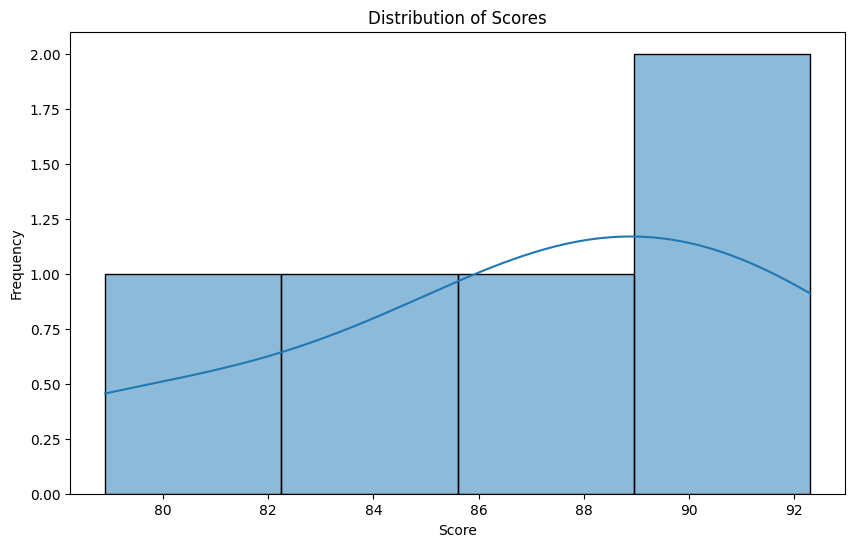

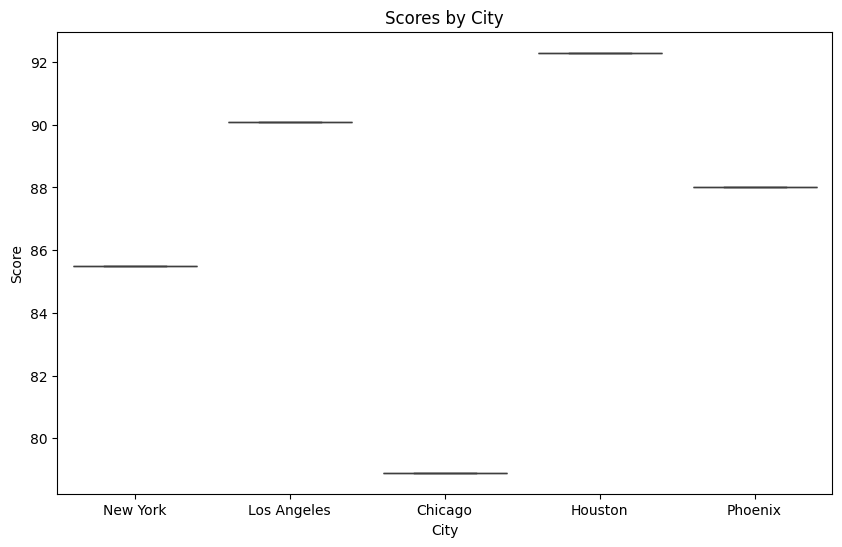

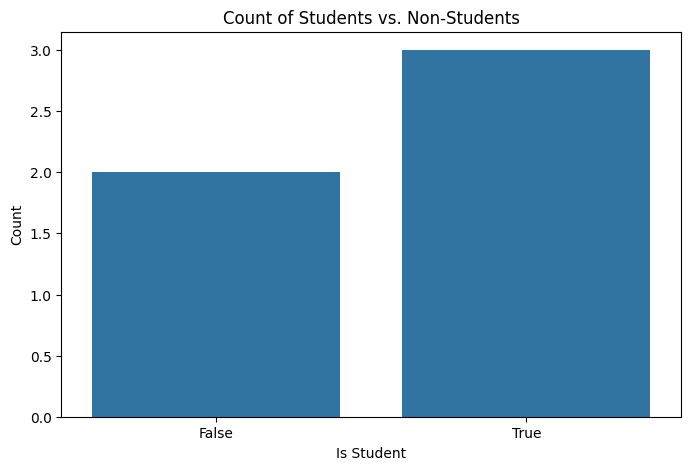

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Score'], kde=True)
plt.title('Distribution of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='City', y='Score', data=df)
plt.title('Scores by City')
plt.xlabel('City')
plt.ylabel('Score')
plt.show()

plt.figure(figsize=(8, 5))
sns.countplot(x='Is_Student', data=df)
plt.title('Count of Students vs. Non-Students')
plt.xlabel('Is Student')
plt.ylabel('Count')
plt.show()